<a href="https://colab.research.google.com/github/marcdaveon345-cell/Data-Science-Lab-Work/blob/main/Fun_Project/productivity_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 AI-Powered Personal Productivity Dashboard

**Author:** Marc Daveon
**Version:** 1.0  
**Last Updated:** March 2026

---

## 📌 Project Overview

This notebook provides a comprehensive **Personal Productivity Dashboard** that helps you:

-  Visualize how you spend your time across different categories
-  Analyze daily and weekly productivity trends
-  Extract meaningful insights from your task data
-  Predict future productivity using Linear Regression

### Categories Tracked
| Category | Description |
|----------|-------------|
|  Study | Learning, courses, reading |
|  Fitness | Exercise, sports, health |
|  Work | Professional tasks, meetings |
|  Leisure | Entertainment, hobbies, rest |

---

> **How to use:** Run each cell in order. You can either use the built-in sample dataset or upload your own CSV file.

---
## Section 1: Install & Import Libraries

We start by installing any missing libraries and importing everything we need.
- **pandas** — data manipulation and analysis
- **matplotlib / seaborn** — visualization
- **scikit-learn** — machine learning (linear regression)
- **numpy** — numerical operations

In [1]:
# Install required libraries (only needed in Colab if not pre-installed)
!pip install pandas matplotlib seaborn scikit-learn numpy --quiet

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [2]:
# ─── Core Libraries ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
from datetime import datetime, timedelta
from io import StringIO

# ─── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# ─── Google Colab Utilities ───────────────────────────────────────────────────
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ─── Display Settings ─────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set a clean, professional style for all plots
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})

# Custom color palette for the 4 categories
CATEGORY_COLORS = {
    'Study':   '#4C72B0',
    'Work':    '#DD8452',
    'Fitness': '#55A868',
    'Leisure': '#C44E52'
}
PALETTE = list(CATEGORY_COLORS.values())

print("✅ Libraries imported successfully!")
print(f"   Running in Google Colab: {IN_COLAB}")

✅ Libraries imported successfully!
   Running in Google Colab: True


---
## Section 2: Load Data

You have **two options**:

1. **Option A** *(Recommended for beginners)*: Use the auto-generated sample dataset — 90 days of realistic productivity data is created for you automatically.
2. **Option B**: Upload your own CSV file with the following columns:
   - `task` — name of the task (string)
   - `hours` — time spent in hours (float)
   - `category` — one of: Study, Work, Fitness, Leisure
   - `date` — date in `YYYY-MM-DD` format

Set `USE_SAMPLE_DATA = True` to use sample data, or `False` to upload your own.

In [3]:
# ─── Configuration ────────────────────────────────────────────────────────────
USE_SAMPLE_DATA = True   # ← Change to False to upload your own CSV

# ─── Option A: Generate Sample Dataset ───────────────────────────────────────
def generate_sample_data(num_days=90, seed=42):
    """
    Generates a realistic sample productivity dataset.
    Simulates daily habits with natural variation and patterns.
    """
    np.random.seed(seed)

    tasks_by_category = {
        'Study':   ['Online Course', 'Reading Book', 'Practice Problems',
                    'Research Paper', 'Note Taking', 'Revision'],
        'Work':    ['Client Meeting', 'Code Review', 'Report Writing',
                    'Email Management', 'Project Planning', 'Debugging'],
        'Fitness': ['Morning Run', 'Gym Session', 'Yoga', 'Cycling',
                    'Swimming', 'HIIT Workout'],
        'Leisure': ['Netflix', 'Gaming', 'Social Media', 'Cooking',
                    'Music Practice', 'Reading Fiction']
    }

    # Simulate a slight upward trend in productive hours over time
    trend = np.linspace(0, 1.5, num_days)

    records = []
    start_date = datetime.today() - timedelta(days=num_days)

    for day_idx in range(num_days):
        current_date = start_date + timedelta(days=day_idx)
        is_weekend = current_date.weekday() >= 5  # Saturday=5, Sunday=6

        # Each day has 2–4 tasks logged
        num_tasks = np.random.randint(2, 5)

        # Adjust category probabilities: more leisure on weekends
        if is_weekend:
            cat_probs = [0.20, 0.10, 0.30, 0.40]
        else:
            cat_probs = [0.30, 0.40, 0.15, 0.15]

        chosen_categories = np.random.choice(
            list(tasks_by_category.keys()),
            size=num_tasks,
            replace=True,
            p=cat_probs
        )

        for cat in chosen_categories:
            task_name = np.random.choice(tasks_by_category[cat])
            # Hours: base + trend effect + random noise
            base_hours = {'Study': 2.0, 'Work': 3.0, 'Fitness': 1.0, 'Leisure': 1.5}[cat]
            hours = round(
                max(0.25, base_hours + trend[day_idx] * 0.1 + np.random.normal(0, 0.4)),
                2
            )
            records.append({
                'task':     task_name,
                'hours':    hours,
                'category': cat,
                'date':     current_date.strftime('%Y-%m-%d')
            })

    return pd.DataFrame(records)


# ─── Option B: Upload CSV ─────────────────────────────────────────────────────
def upload_csv():
    """Handles CSV upload in Google Colab environment."""
    if IN_COLAB:
        print("📁 Please select your CSV file...")
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        return pd.read_csv(StringIO(uploaded[filename].decode('utf-8')))
    else:
        # For local Jupyter: place your CSV next to the notebook
        csv_path = input("Enter path to your CSV file: ").strip()
        return pd.read_csv(csv_path)


# ─── Load Data Based on Choice ────────────────────────────────────────────────
if USE_SAMPLE_DATA:
    df_raw = generate_sample_data(num_days=90)
    print("✅ Sample dataset generated successfully!")
else:
    df_raw = upload_csv()
    print("✅ CSV uploaded successfully!")

# Preview
print(f"\n📊 Dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"   Date range: {df_raw['date'].min()} → {df_raw['date'].max()}")
df_raw.head(10)

✅ Sample dataset generated successfully!

📊 Dataset shape: 267 rows × 4 columns
   Date range: 2025-12-27 → 2026-03-26


,task,hours,category,date
0,Gaming,1.61,Leisure,2025-12-27
1,Practice Problems,2.40,Study,2025-12-27
2,Reading Fiction,1.53,Leisure,2025-12-27
3,HIIT Workout,0.94,Fitness,2025-12-27
4,Reading Book,0.96,Study,2025-12-28
5,Netflix,1.88,Leisure,2025-12-28
6,Social Media,1.10,Leisure,2025-12-28
7,Client Meeting,3.13,Work,2025-12-29
8,Yoga,1.17,Fitness,2025-12-29
9,Online Course,2.34,Study,2025-12-29


---
##  Section 3: Data Cleaning & Preprocessing

Before analysing anything, we need to ensure data quality.

Steps:
1. Convert `date` column to proper `datetime` type
2. Extract useful time features (week number, day name, month)
3. Check for and handle missing values & duplicates
4. Validate hours are within a sensible range (0–16 hrs/task)
5. Standardise category names (strip whitespace, title-case)

In [4]:
def clean_and_preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans and enriches the raw productivity DataFrame.
    Returns a fully processed copy.
    """
    df = df.copy()

    # ── Step 1: Standardise column names ─────────────────────────────────────
    df.columns = df.columns.str.strip().str.lower()

    # ── Step 2: Convert date column ───────────────────────────────────────────
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    # ── Step 3: Standardise text fields ───────────────────────────────────────
    df['category'] = df['category'].str.strip().str.title()
    df['task']     = df['task'].str.strip().str.title()

    # ── Step 4: Validate & clip hours ─────────────────────────────────────────
    df['hours'] = pd.to_numeric(df['hours'], errors='coerce')
    df['hours'] = df['hours'].clip(lower=0.0, upper=16.0)

    # ── Step 5: Drop rows with critical nulls ─────────────────────────────────
    before = len(df)
    df.dropna(subset=['date', 'hours', 'category'], inplace=True)
    dropped = before - len(df)
    if dropped:
        print(f"   ⚠️  Dropped {dropped} rows with missing critical values.")

    # ── Step 6: Remove duplicate entries ──────────────────────────────────────
    dupes = df.duplicated().sum()
    df.drop_duplicates(inplace=True)
    if dupes:
        print(f"   ⚠️  Removed {dupes} duplicate rows.")

    # ── Step 7: Feature engineering ───────────────────────────────────────────
    df['day_name']   = df['date'].dt.day_name()          # e.g., 'Monday'
    df['week_num']   = df['date'].dt.isocalendar().week.astype(int)
    df['month_name'] = df['date'].dt.strftime('%b %Y')   # e.g., 'Jan 2025'
    df['is_weekend'] = df['date'].dt.weekday >= 5        # True/False
    df['day_of_year']= df['date'].dt.dayofyear

    return df.sort_values('date').reset_index(drop=True)


# ─── Run Cleaning ─────────────────────────────────────────────────────────────
df = clean_and_preprocess(df_raw)

print("✅ Data cleaning complete!")
print("\n" + "═" * 45)
print("  DATA QUALITY REPORT")
print("═" * 45)
print(f"  Total records    : {len(df):,}")
print(f"  Unique dates     : {df['date'].nunique()}")
print(f"  Categories found : {sorted(df['category'].unique())}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Avg hours/task   : {df['hours'].mean():.2f} hrs")
print(f"  Max hours/task   : {df['hours'].max():.2f} hrs")
print("═" * 45)

# Show data types
print("\n📋 Column Info:")
df.dtypes

✅ Data cleaning complete!

═════════════════════════════════════════════
  DATA QUALITY REPORT
═════════════════════════════════════════════
  Total records    : 267
  Unique dates     : 90
  Categories found : ['Fitness', 'Leisure', 'Study', 'Work']
  Missing values   : 0
  Avg hours/task   : 2.10 hrs
  Max hours/task   : 4.01 hrs
═════════════════════════════════════════════

📋 Column Info:


,0
task,object
hours,float64
category,object
date,datetime64[ns]
day_name,object
week_num,int64
month_name,object
is_weekend,bool
day_of_year,int32


**bold text**---
##  Section 4: Exploratory Data Analysis (EDA)

Before visualising, let's build summary tables that answer key questions:
- How many hours per category overall?
- What is the daily total productivity?
- How does productivity differ by day of week?
- Which week was the most productive?

In [5]:
# ─── 4.1 Total Hours by Category ─────────────────────────────────────────────
category_summary = (
    df.groupby('category')['hours']
    .agg(total_hours='sum', avg_hours='mean', task_count='count')
    .round(2)
    .sort_values('total_hours', ascending=False)
)
category_summary['% of total'] = (
    category_summary['total_hours'] / category_summary['total_hours'].sum() * 100
).round(1)

print("📌 Summary by Category:")
print(category_summary.to_string())

# ─── 4.2 Daily Total Hours ────────────────────────────────────────────────────
daily_hours = (
    df.groupby('date')['hours']
    .sum()
    .reset_index()
    .rename(columns={'hours': 'total_hours'})
)

# ─── 4.3 Weekly Total Hours ───────────────────────────────────────────────────
weekly_hours = (
    df.groupby('week_num')['hours']
    .sum()
    .reset_index()
    .rename(columns={'hours': 'total_hours'})
)

# ─── 4.4 Hours by Day of Week ────────────────────────────────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_summary = (
    df.groupby('day_name')['hours']
    .mean()
    .reindex(day_order)
    .reset_index()
    .rename(columns={'hours': 'avg_hours'})
)

print("\n📅 Average Hours by Day of Week:")
print(day_summary.to_string(index=False))

# ─── 4.5 Most Productive Week ────────────────────────────────────────────────
best_week = weekly_hours.loc[weekly_hours['total_hours'].idxmax()]
print(f"\n🏆 Most productive week: Week #{int(best_week['week_num'])} "
      f"with {best_week['total_hours']:.1f} hours logged")

📌 Summary by Category:
          total_hours  avg_hours  task_count  % of total
category                                                
Work           274.96       3.09          89       49.00
Study          135.86       2.16          63       24.20
Leisure         90.65       1.56          58       16.20
Fitness         59.58       1.05          57       10.60

📅 Average Hours by Day of Week:
 day_name  avg_hours
   Monday       2.37
  Tuesday       2.35
Wednesday       2.23
 Thursday       2.16
   Friday       2.39
 Saturday       1.68
   Sunday       1.53

🏆 Most productive week: Week #12 with 54.5 hours logged


---
##  Section 5: Visualisations

Now we bring the data to life with four polished charts:

| Chart | What it shows |
|-------|---------------|
| 📊 Bar Chart | Total time spent per category |
| 📉 Line Chart | Daily productivity over time |
| 🥧 Pie Chart | Proportional category breakdown |
| 📅 Heatmap | Productivity pattern by day of week |


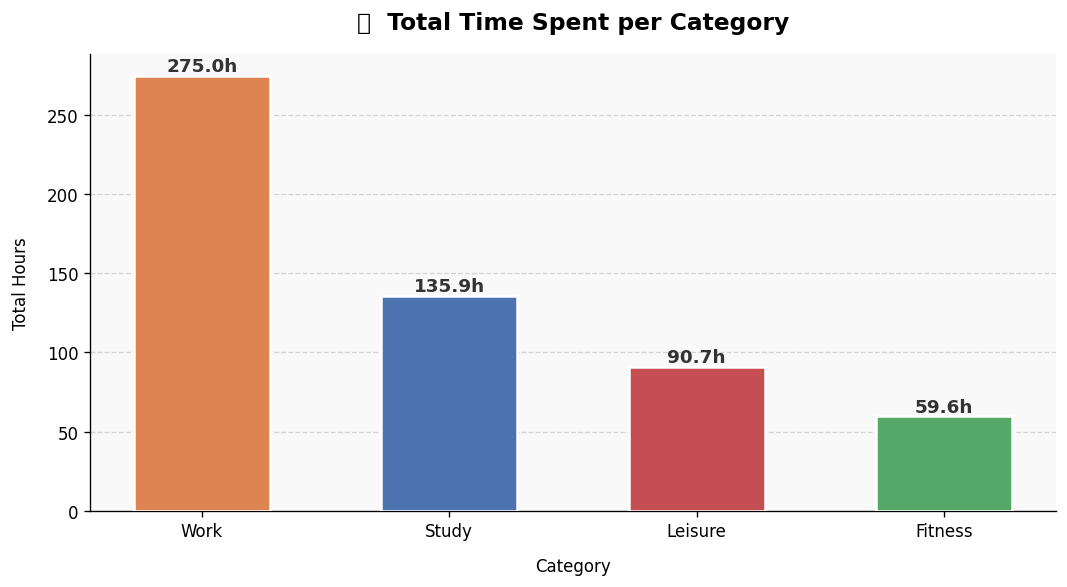

✅ Bar chart saved as chart_bar.png


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHART 1: Bar Chart — Time Spent per Category
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 5))

cats    = category_summary.index.tolist()
totals  = category_summary['total_hours'].values
colors  = [CATEGORY_COLORS.get(c, '#888') for c in cats]

bars = ax.bar(cats, totals, color=colors, width=0.55, zorder=3, edgecolor='white', linewidth=1.5)

# Annotate each bar with the value
for bar, val in zip(bars, totals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}h',
        ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333'
    )

ax.set_title('⏱️  Total Time Spent per Category', pad=15)
ax.set_xlabel('Category', labelpad=10)
ax.set_ylabel('Total Hours', labelpad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('chart_bar.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Bar chart saved as chart_bar.png")

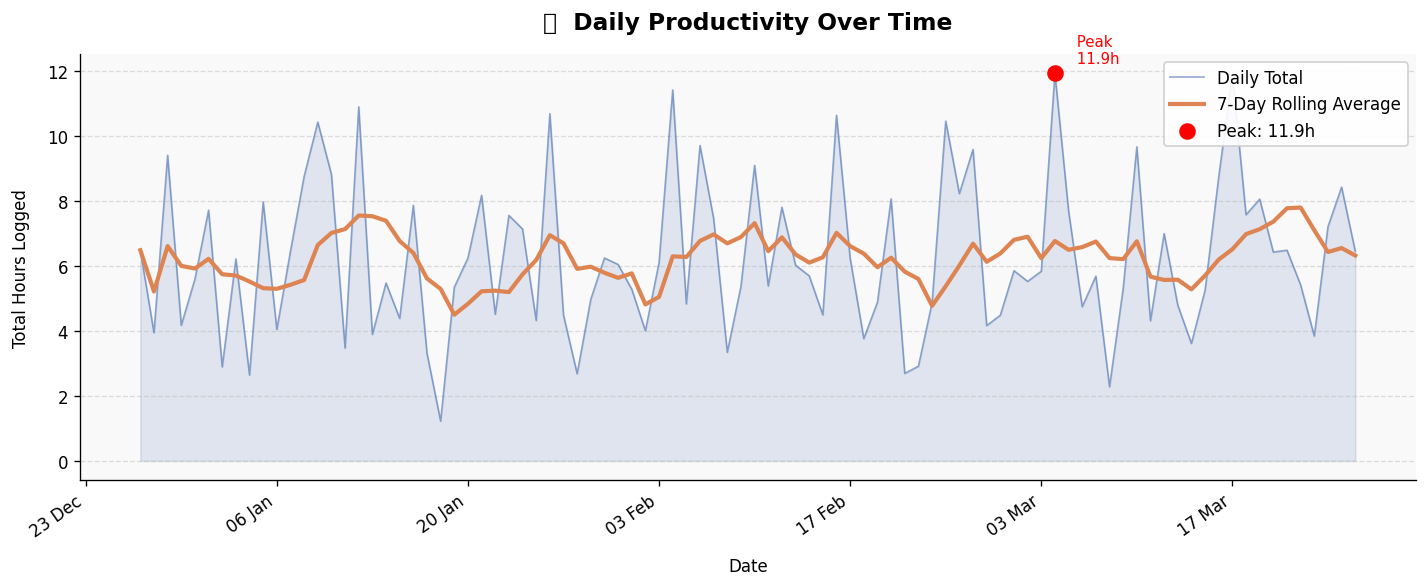

✅ Line chart saved as chart_line.png


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHART 2: Line Chart — Daily Productivity Over Time
# ═══════════════════════════════════════════════════════════════════════════════

# Compute a 7-day rolling average to smooth noise
daily_hours['rolling_7d'] = daily_hours['total_hours'].rolling(window=7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))

# Shaded area under raw line
ax.fill_between(daily_hours['date'], daily_hours['total_hours'],
                alpha=0.15, color='#4C72B0')

# Raw daily line
ax.plot(daily_hours['date'], daily_hours['total_hours'],
        color='#4C72B0', linewidth=1.0, alpha=0.6, label='Daily Total')

# Smooth 7-day average
ax.plot(daily_hours['date'], daily_hours['rolling_7d'],
        color='#DD8452', linewidth=2.5, label='7-Day Rolling Average')

# Mark the peak day
peak_idx = daily_hours['total_hours'].idxmax()
peak_row = daily_hours.loc[peak_idx]
ax.scatter(peak_row['date'], peak_row['total_hours'],
           color='red', s=80, zorder=5, label=f"Peak: {peak_row['total_hours']:.1f}h")
ax.annotate(f" Peak\n {peak_row['total_hours']:.1f}h",
            xy=(peak_row['date'], peak_row['total_hours']),
            xytext=(10, 6), textcoords='offset points',
            fontsize=9, color='red')

# Format x-axis dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=35, ha='right')

ax.set_title('📅  Daily Productivity Over Time', pad=15)
ax.set_xlabel('Date', labelpad=10)
ax.set_ylabel('Total Hours Logged', labelpad=10)
ax.legend(framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('chart_line.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Line chart saved as chart_line.png")

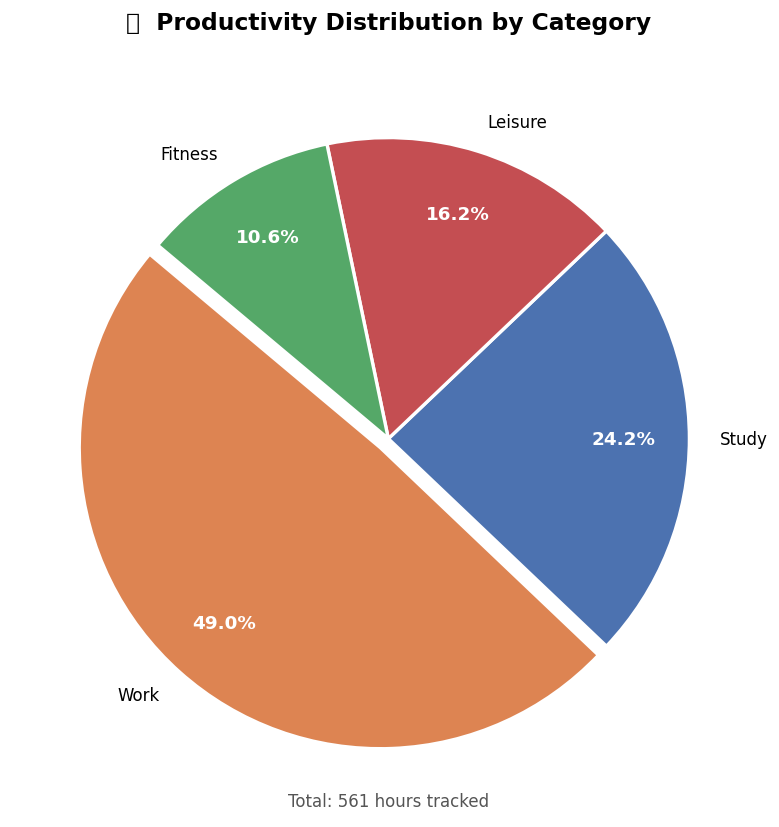

✅ Pie chart saved as chart_pie.png


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHART 3: Pie Chart — Category Distribution
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(7, 7))

sizes  = category_summary['total_hours'].values
labels = category_summary.index.tolist()
colors = [CATEGORY_COLORS.get(c, '#888') for c in labels]

# Explode the top category slightly
explode = [0.04 if i == 0 else 0 for i in range(len(labels))]

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

# Style the percentage labels
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title('🥧  Productivity Distribution by Category', pad=20, fontsize=14)

# Add total hours as a subtitle
total_hrs = df['hours'].sum()
ax.text(0, -1.22, f'Total: {total_hrs:.0f} hours tracked',
        ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.savefig('chart_pie.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Pie chart saved as chart_pie.png")

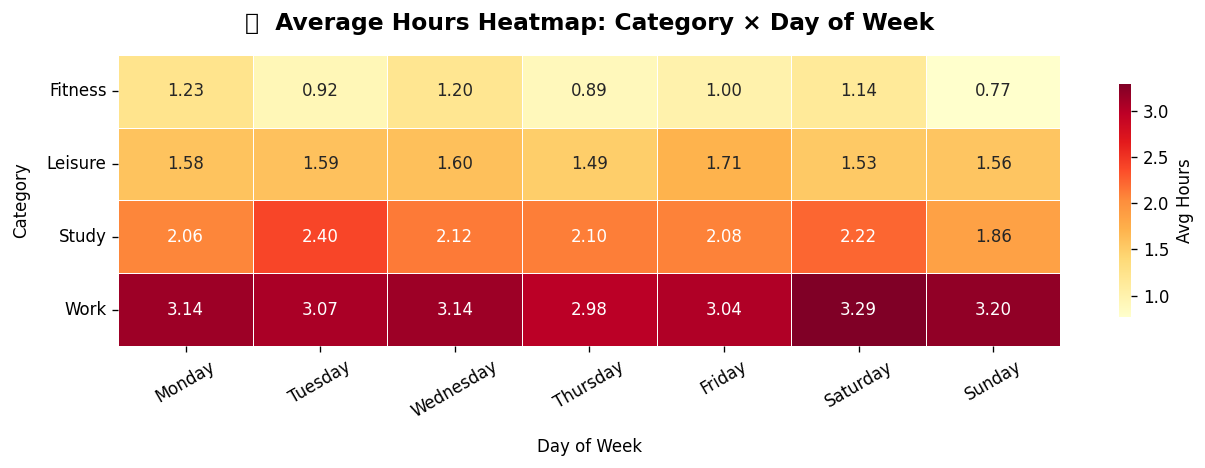

✅ Heatmap saved as chart_heatmap.png


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHART 4: Heatmap — Average Hours by Category × Day of Week
# ═══════════════════════════════════════════════════════════════════════════════

pivot = (
    df.groupby(['category', 'day_name'])['hours']
    .mean()
    .unstack('day_name')
    .reindex(columns=day_order)
    .fillna(0)
    .round(2)
)

fig, ax = plt.subplots(figsize=(11, 4))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Avg Hours', 'shrink': 0.8}
)

ax.set_title('🔥  Average Hours Heatmap: Category × Day of Week', pad=15)
ax.set_xlabel('Day of Week', labelpad=10)
ax.set_ylabel('Category', labelpad=10)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('chart_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved as chart_heatmap.png")

---
##  Section 6: AI-Generated Insights

Let's use the data to automatically generate **personalised, actionable insights** — just like a personal productivity coach would!

The engine calculates metrics and formats them into human-readable observations.

In [10]:
def generate_insights(df, daily_hours, category_summary):
    """
    Analyses the productivity data and prints a set of
    personalised, human-readable insights.
    """
    print("\n" + "═" * 55)
    print("  🤖  YOUR PERSONALISED PRODUCTIVITY INSIGHTS")
    print("═" * 55)

    total_hours = df['hours'].sum()
    total_days  = df['date'].nunique()
    avg_per_day = total_hours / total_days

    # ── Insight 1: Top category ───────────────────────────────────────────────
    top_cat     = category_summary.index[0]
    top_hours   = category_summary.loc[top_cat, 'total_hours']
    top_pct     = category_summary.loc[top_cat, '% of total']
    print(f"\n  📌 #1  DOMINANT CATEGORY")
    print(f"        You spend the most time on → [{top_cat}]")
    print(f"        ({top_hours:.0f} hours | {top_pct:.1f}% of all tracked time)")

    # ── Insight 2: Least-invested category ───────────────────────────────────
    low_cat   = category_summary.index[-1]
    low_hours = category_summary.loc[low_cat, 'total_hours']
    print(f"\n  📌 #2  AREA WITH GROWTH POTENTIAL")
    print(f"        Your least-invested category is → [{low_cat}]")
    print(f"        Only {low_hours:.0f} hours logged. Consider allocating more time here.")

    # ── Insight 3: Best day of week ───────────────────────────────────────────
    day_totals   = df.groupby('day_name')['hours'].mean().reindex(day_order)
    best_day     = day_totals.idxmax()
    best_day_avg = day_totals.max()
    worst_day    = day_totals.idxmin()
    print(f"\n  📌 #3  YOUR POWER DAY")
    print(f"        Most productive day of the week → [{best_day}]")
    print(f"        Average of {best_day_avg:.2f} hrs/day. Schedule important work here!")
    print(f"        Least active day → [{worst_day}] (consider planning rest or leisure)")

    # ── Insight 4: Weekend vs Weekday ─────────────────────────────────────────
    wk_avg  = df[~df['is_weekend']]['hours'].mean()
    wkd_avg = df[ df['is_weekend']]['hours'].mean()
    diff    = abs(wk_avg - wkd_avg)
    more_on = "Weekdays" if wk_avg > wkd_avg else "Weekends"
    print(f"\n  📌 #4  WEEKDAY vs WEEKEND BALANCE")
    print(f"        Weekday avg: {wk_avg:.2f} hrs/task  |  Weekend avg: {wkd_avg:.2f} hrs/task")
    print(f"        You are {diff:.2f} hrs/task more productive on {more_on}.")

    # ── Insight 5: Overall daily average ──────────────────────────────────────
    print(f"\n  📌 #5  OVERALL STATS")
    print(f"        📆 Days tracked         : {total_days}")
    print(f"        ⏱️  Total hours logged   : {total_hours:.1f} hrs")
    print(f"        📊 Daily average        : {avg_per_day:.2f} hrs/day")

    # ── Insight 6: Consistency score ─────────────────────────────────────────
    cv = daily_hours['total_hours'].std() / daily_hours['total_hours'].mean()
    consistency = "🌟 Excellent" if cv < 0.3 else ("👍 Good" if cv < 0.5 else "⚠️  Needs Work")
    print(f"\n  📌 #6  CONSISTENCY SCORE: {consistency}")
    print(f"        Coefficient of variation: {cv:.2f} (lower = more consistent)")

    print("\n" + "═" * 55)


generate_insights(df, daily_hours, category_summary)


═══════════════════════════════════════════════════════
  🤖  YOUR PERSONALISED PRODUCTIVITY INSIGHTS
═══════════════════════════════════════════════════════

  📌 #1  DOMINANT CATEGORY
        You spend the most time on → [Work]
        (275 hours | 49.0% of all tracked time)

  📌 #2  AREA WITH GROWTH POTENTIAL
        Your least-invested category is → [Fitness]
        Only 60 hours logged. Consider allocating more time here.

  📌 #3  YOUR POWER DAY
        Most productive day of the week → [Friday]
        Average of 2.39 hrs/day. Schedule important work here!
        Least active day → [Sunday] (consider planning rest or leisure)

  📌 #4  WEEKDAY vs WEEKEND BALANCE
        Weekday avg: 2.30 hrs/task  |  Weekend avg: 1.62 hrs/task
        You are 0.68 hrs/task more productive on Weekdays.

  📌 #5  OVERALL STATS
        📆 Days tracked         : 90
        ⏱️  Total hours logged   : 561.1 hrs
        📊 Daily average        : 6.23 hrs/day

  📌 #6  CONSISTENCY SCORE: 👍 Good
        Coeff

---
##  Section 7: Predicting Future Productivity (Linear Regression)

Using **scikit-learn's Linear Regression**, we model the relationship between time (day number) and total daily hours logged.

This allows us to:
- Spot overall improvement or decline trends
- Forecast expected productivity for the next 14 days
- Evaluate the model using R² and MAE metrics

> **Note:** This is a simple univariate model for illustration. Real-world forecasting would use more features.

📐 Model Performance:
   R² Score          : 0.0077  (1.0 = perfect fit)
   Mean Abs. Error   : 1.945 hrs
   Trend (slope)     : +0.0081 hrs/day
   Overall Trend     : 📈 Upward

🔭 14-Day Productivity Forecast:
      date  predicted_hours
2026-03-27             6.60
2026-03-28             6.61
2026-03-29             6.62
2026-03-30             6.63
2026-03-31             6.63
2026-04-01             6.64
2026-04-02             6.65
2026-04-03             6.66
2026-04-04             6.67
2026-04-05             6.67
2026-04-06             6.68
2026-04-07             6.69
2026-04-08             6.70
2026-04-09             6.71


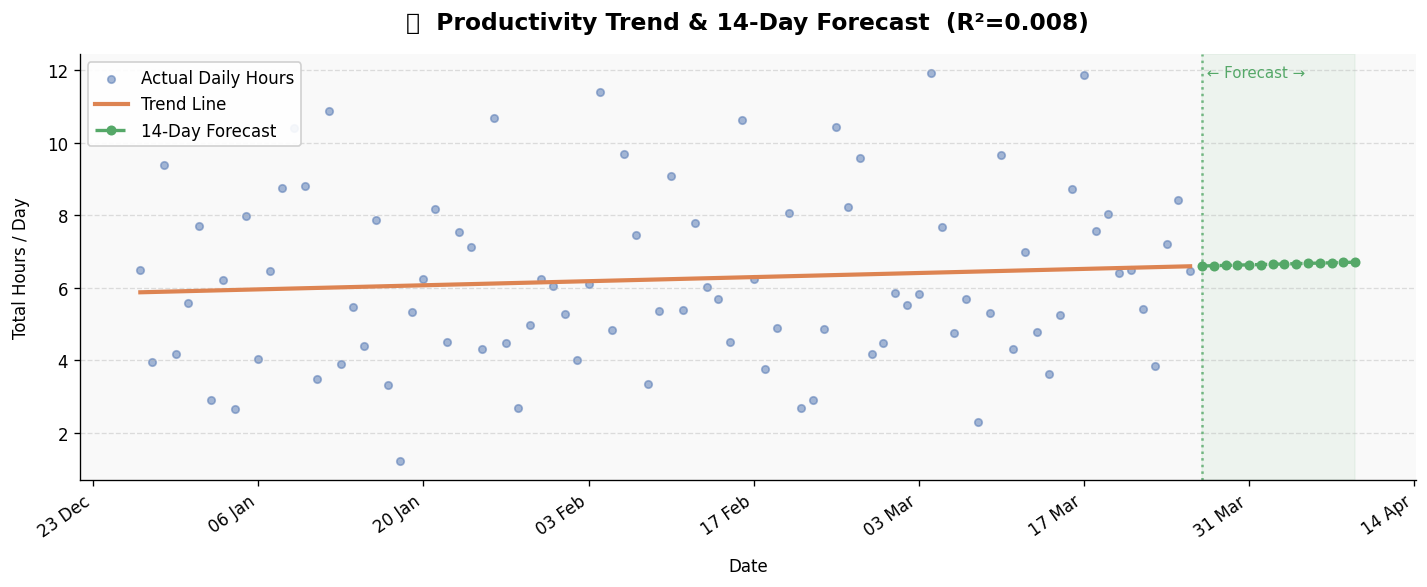

✅ Forecast chart saved as chart_forecast.png


In [11]:
# ─── Prepare Data for Regression ─────────────────────────────────────────────
# Use day-of-year as the numeric feature (X) and total daily hours as target (y)
reg_df = daily_hours.copy()
reg_df['day_num'] = (reg_df['date'] - reg_df['date'].min()).dt.days

X = reg_df[['day_num']].values
y = reg_df['total_hours'].values

# ─── Train Linear Regression ──────────────────────────────────────────────────
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
r2  = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("📐 Model Performance:")
print(f"   R² Score          : {r2:.4f}  (1.0 = perfect fit)")
print(f"   Mean Abs. Error   : {mae:.3f} hrs")
print(f"   Trend (slope)     : {model.coef_[0]:+.4f} hrs/day")

trend_direction = "📈 Upward" if model.coef_[0] > 0 else "📉 Downward"
print(f"   Overall Trend     : {trend_direction}")

# ─── Predict Next 14 Days ─────────────────────────────────────────────────────
last_day  = reg_df['day_num'].max()
last_date = reg_df['date'].max()

future_days  = np.arange(last_day + 1, last_day + 15).reshape(-1, 1)
future_dates = [last_date + timedelta(days=i) for i in range(1, 15)]
future_pred  = model.predict(future_days).clip(min=0.5)  # floor at 30 mins

future_df = pd.DataFrame({'date': future_dates, 'predicted_hours': future_pred.round(2)})

print("\n🔭 14-Day Productivity Forecast:")
print(future_df.to_string(index=False))

# ─── Plot: Actual vs Predicted ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

# Actual data
ax.scatter(reg_df['date'], y, color='#4C72B0', alpha=0.5, s=20, label='Actual Daily Hours')

# Regression line on historical data
ax.plot(reg_df['date'], y_pred, color='#DD8452', linewidth=2.5, label='Trend Line')

# Future predictions
ax.plot(future_dates, future_pred, color='#55A868', linewidth=2, linestyle='--',
        marker='o', markersize=5, label='14-Day Forecast')

# Shade the forecast region
ax.axvspan(future_dates[0], future_dates[-1], alpha=0.07, color='#55A868')
ax.axvline(future_dates[0], color='#55A868', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(future_dates[0], ax.get_ylim()[1] * 0.95, ' ← Forecast →',
        fontsize=9, color='#55A868')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=35, ha='right')

ax.set_title(f'🔮  Productivity Trend & 14-Day Forecast  (R²={r2:.3f})', pad=15)
ax.set_xlabel('Date', labelpad=10)
ax.set_ylabel('Total Hours / Day', labelpad=10)
ax.legend(framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('chart_forecast.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Forecast chart saved as chart_forecast.png")

---
##  Section 8: Export Results

Export the cleaned dataset and summary reports so you can use them in other tools (Excel, Google Sheets, etc.).

In [12]:
# ─── Export Cleaned Data ──────────────────────────────────────────────────────
df.to_csv('productivity_clean.csv', index=False)
category_summary.to_csv('category_summary.csv')
daily_hours.to_csv('daily_summary.csv', index=False)
future_df.to_csv('forecast.csv', index=False)

print("✅ Files exported:")
print("   📄 productivity_clean.csv  — full cleaned dataset")
print("   📄 category_summary.csv    — summary by category")
print("   📄 daily_summary.csv       — daily totals")
print("   📄 forecast.csv            — 14-day forecast")
print("   🖼️  chart_bar.png")
print("   🖼️  chart_line.png")
print("   🖼️  chart_pie.png")
print("   🖼️  chart_heatmap.png")
print("   🖼️  chart_forecast.png")

# In Colab, offer direct download
if IN_COLAB:
    print("\n📥 Downloading files to your computer...")
    for fname in ['productivity_clean.csv','category_summary.csv',
                  'daily_summary.csv','forecast.csv',
                  'chart_bar.png','chart_line.png',
                  'chart_pie.png','chart_heatmap.png','chart_forecast.png']:
        try:
            files.download(fname)
        except Exception:
            pass

✅ Files exported:
   📄 productivity_clean.csv  — full cleaned dataset
   📄 category_summary.csv    — summary by category
   📄 daily_summary.csv       — daily totals
   📄 forecast.csv            — 14-day forecast
   🖼️  chart_bar.png
   🖼️  chart_line.png
   🖼️  chart_pie.png
   🖼️  chart_heatmap.png
   🖼️  chart_forecast.png

📥 Downloading files to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
##  Conclusion

Congratulations on running your **AI-Powered Productivity Dashboard**!

### What you accomplished:
- ✅ Generated / loaded and cleaned a real productivity dataset
- ✅ Built 4 professional data visualisations
- ✅ Extracted 6 personalised productivity insights
- ✅ Trained a Linear Regression model to forecast future productivity
- ✅ Exported all results to CSV and PNG

### 🚀 Ideas to Extend This Project
- Connect to Google Calendar or Notion API to pull real data automatically
- Add a Pomodoro timer tracker integration
- Use a more advanced model (Prophet, ARIMA) for time-series forecasting
- Build a Streamlit or Gradio web app for an interactive dashboard
- Add goal-setting: set weekly hour targets per category and track progress

---

*Made with ❤️ using Python, pandas, matplotlib, seaborn, and scikit-learn*